# Matrix Masking Encryption & Low-VRAM Domain Generalization (OrganAMNIST)

## 1. Specification of Dependencies & Data Setup
In accordance with NeurIPS guidelines for research code reproducibility, this section explicitly outlines the environment, required libraries, and datasets necessary to execute this framework.

**Dependencies:**
* `torch`, `torchvision`, `medmnist`, `scikit-learn`, `matplotlib`, `seaborn`, `pandas`
* These dependencies can be installed via the inline pip command below. A CUDA-enabled GPU is required to leverage the PyTorch hardware acceleration and Mixed Precision (`torch.autocast`) implemented in this notebook.

**Dataset (OrganAMNIST - 28x28):**
* We use the `organamnist` split from the official MedMNIST collection. The code below will automatically download and process the dataset, requiring no manual directory setup from the user.

**The Static Encryption Framework (Dynamic Chunking):**
To ensure the hospital's encryption overhead remains minimal, we generate static orthogonal masks based on class distributions. The smallest class size dictates the chunk size ($N$) to maintain perfect alignment. The data is encrypted locally and prepared for Cloud Training.

In [ ]:
# --- Installation & Dataset Download ---
!pip install -q scikit-learn matplotlib seaborn torchvision medmnist

import os
# Prevent CUDA memory fragmentation
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import time
import copy
import gc
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split
import torchvision.transforms as T
import medmnist
from medmnist import INFO
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import random

# --- HARDWARE ACCELERATION ---
torch.backends.cudnn.benchmark = True

# Force a deep clean of the GPU VRAM
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Core Row Mask Generator (GPU Optimized) ---
def generate_row_mask_gpu(y_batch, n, device, seed=None):
    if seed is not None: torch.manual_seed(seed)
    u = torch.ones(n, 1, device=device) / (n ** 0.5)
    y = y_batch.view(n, 1).float()
    proj = (y.t() @ u) * u
    y_ortho = y - proj
    norm_y = torch.norm(y_ortho)

    if norm_y < 1e-6:
        fixed_basis = u
        k = 1
    else:
        y_ortho = y_ortho / norm_y
        fixed_basis = torch.cat([u, y_ortho], dim=1)
        k = 2

    M = torch.randn(n, n, device=device)
    M[:, :k] = fixed_basis
    Q, _ = torch.linalg.qr(M)

    n_noise = n - k
    rand_noise = torch.randn(n_noise, n_noise, device=device)
    W, _ = torch.linalg.qr(rand_noise)

    Q_fixed = fixed_basis
    Q_noise = Q[:, k:]

    return (Q_fixed @ Q_fixed.t()) + (Q_noise @ W @ Q_noise.t())

print("\n=====================================================================")
print("ORGANAMNIST: FIGSHARE LOGIC (PARTIAL UNFREEZE + LOW VRAM)")
print("=====================================================================")

# NATIVE MEDMNIST CONFIGURATION
IMAGE_SIZE = 28
IMAGE_DIM = IMAGE_SIZE * IMAGE_SIZE

transform_vector = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[.5], std=[.5]),
    T.Lambda(lambda x: x.view(-1))
])

# MedMNIST Automated Loading Protocol
data_flag = 'organamnist'
info = INFO[data_flag]
num_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])

print(f"Loading {data_flag} Dataset ({IMAGE_SIZE}x{IMAGE_SIZE}) with {num_classes} classes...")
train_dataset_full = DataClass(split='train', transform=transform_vector, download=True)
test_dataset_full = DataClass(split='test', transform=transform_vector, download=True)

def create_chunked_static_masked_dataset(dataset_subset, device, is_train=True):
    loader = DataLoader(dataset_subset, batch_size=len(dataset_subset), shuffle=False)
    X_all, Y_all = next(iter(loader))

    # MEDMNIST FIX: Squeeze the (N, 1) label array into a flat (N,) vector
    Y_all = Y_all.squeeze().long()

    class_counts = torch.bincount(Y_all)
    N = int(torch.min(class_counts[class_counts > 0]).item())

    if is_train:
        print(f"\n-> Dynamic Chunking: Smallest class dictates Chunk Size = {N}.")

    X_masked_list, Y_list = [], []
    unique_classes = torch.unique(Y_all)

    for cls in unique_classes:
        indices = (Y_all == cls).nonzero(as_tuple=True)[0]
        num_chunks = len(indices) // N

        for i in range(num_chunks):
            idx_chunk = indices[i*N : (i+1)*N]
            X_sub = X_all[idx_chunk].to(device)
            Y_sub = Y_all[idx_chunk].to(device)

            if N > 1:
                A_mask = generate_row_mask_gpu(Y_sub, N, device)
                X_sub_masked = torch.matmul(A_mask, X_sub)
            else:
                X_sub_masked = X_sub

            X_masked_list.append(X_sub_masked.cpu())
            Y_list.append(Y_sub.cpu())

            del X_sub, Y_sub, X_sub_masked
            if N > 1: del A_mask
            torch.cuda.empty_cache()

    return TensorDataset(torch.cat(X_masked_list, dim=0), torch.cat(Y_list, dim=0))

print("\nEncrypting Data into Static Batches...")
train_masked_ds = create_chunked_static_masked_dataset(train_dataset_full, device, is_train=True)
test_masked_ds = create_chunked_static_masked_dataset(test_dataset_full, device, is_train=False)

gc.collect()
torch.cuda.empty_cache()

Using device: cuda

ORGANAMNIST: FIGSHARE LOGIC (PARTIAL UNFREEZE + LOW VRAM)
Loading organamnist Dataset (28x28) with 11 classes...

Encrypting Data into Static Batches...

-> Dynamic Chunking: Smallest class dictates Chunk Size = 1357.


## 2. Reproducing Visualizations: Matrix Masking Encryption
Model and encryption evaluation often depends on qualitative analysis to ensure privacy bounds are visually respected. The code below contains the exact sequence to reproduce the encryption visualization grid presented in the manuscript.

Executing this cell dynamically samples a random medical organ class, pulls 16 raw images, applies our exact row-mask generator ($L=AX$), and projects the resulting images side-by-side. This confirms that the static mask severely obscures visual features while retaining mathematical structure.


VISUALIZING MATRIX MASKING ENCRYPTION (ORGANAMNIST)


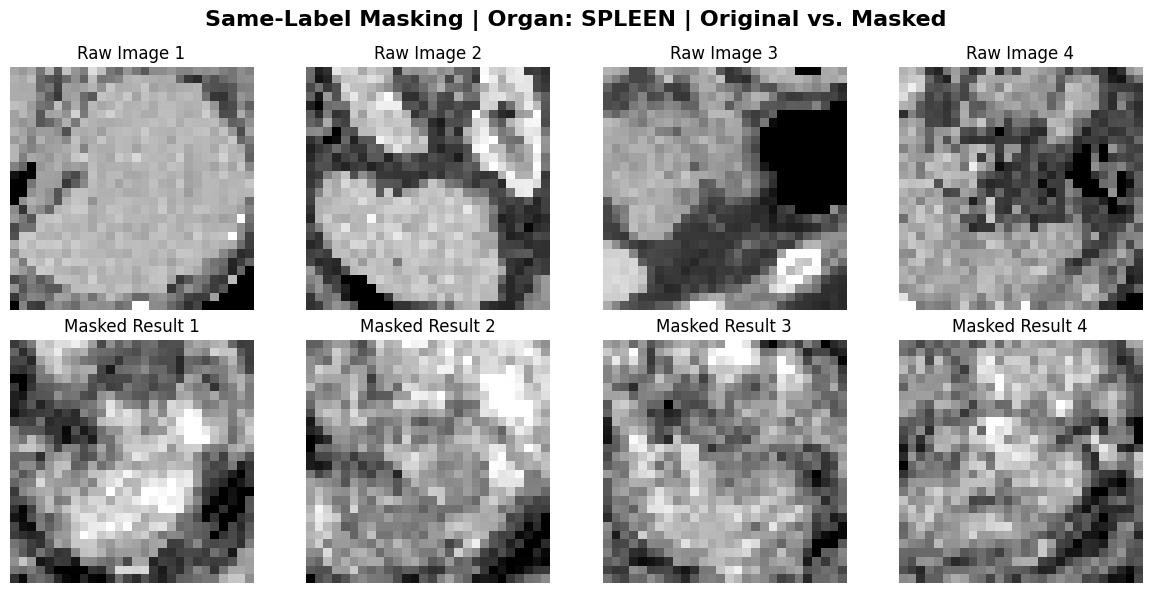

51

In [ ]:
print("\n=====================================================================")
print("VISUALIZING MATRIX MASKING ENCRYPTION (ORGANAMNIST)")
print("=====================================================================")

# Extract squeezed labels for boolean matching
labels_squeezed = np.array(train_dataset_full.labels).squeeze()
unique_classes = np.unique(labels_squeezed)
random_class = random.choice(unique_classes)
class_name = info['label'][str(random_class)]

class_indices = (labels_squeezed == random_class).nonzero()[0]
selected_indices = np.random.choice(class_indices, size=16, replace=False)

X_viz = torch.stack([train_dataset_full[i][0] for i in selected_indices]).to(device)
Y_viz = torch.tensor([train_dataset_full[i][1][0] for i in selected_indices]).to(device)

A_viz = generate_row_mask_gpu(Y_viz, 16, device)
X_viz_masked = A_viz @ X_viz

def unnormalize(tensor):
    return (tensor * 0.5) + 0.5

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle(f"Same-Label Masking | Organ: {class_name.upper()} | Original vs. Masked", fontsize=16, fontweight='bold')

for i in range(4):
    ax_orig = axes[0, i]
    img_orig = unnormalize(X_viz[i]).view(IMAGE_SIZE, IMAGE_SIZE).cpu().numpy()
    ax_orig.imshow(img_orig, cmap='gray', vmin=0, vmax=1)
    ax_orig.set_title(f"Raw Image {i+1}")
    ax_orig.axis('off')

    ax_mask = axes[1, i]
    img_mask = unnormalize(X_viz_masked[i]).view(IMAGE_SIZE, IMAGE_SIZE).cpu().numpy()
    ax_mask.imshow(img_mask, cmap='gray', vmin=0, vmax=1)
    ax_mask.set_title(f"Masked Result {i+1}")
    ax_mask.axis('off')

plt.tight_layout()
plt.show()

del X_viz, Y_viz, A_viz, X_viz_masked
torch.cuda.empty_cache()
gc.collect()

## 3. Evaluation Code & Model Architecture
To ensure complete transparency and allow researchers to build upon our work, we define the exact evaluation loop and model architecture used.

**Evaluation Function (`eval_model_loss_acc`):**
A robust, memory-efficient validation loop using PyTorch Mixed Precision to evaluate both accuracy and CrossEntropyLoss across validation/test loaders.

**Architecture (`DenseNet-121`):**
We utilize `DenseNet-121` initialized with default weights. Crucially, because OrganAMNIST images are heavily downsampled (28x28), we override the initial convolution layer (`conv0`) and bypass the first pooling layer (`pool0`). This prevents the network from destroying spatial dimensions too early in the forward pass.

In [ ]:
# =====================================================================
# 0. HELPER FUNCTION: VALIDATION EVALUATOR
# =====================================================================
def eval_model_loss_acc(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for X_b, Y_b in loader:
            X_b = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
            Y_b = Y_b.squeeze().long().to(device) # MedMNIST label fix

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(X_b)
                loss = criterion(outputs, Y_b)

            running_loss += loss.item() * X_b.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == Y_b).sum().item()
            total += Y_b.size(0)

            del X_b, Y_b, outputs, loss
    return running_loss / total, correct / total

def get_model(model_name, num_classes):
    if model_name == 'DenseNet-121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT, memory_efficient=True)
        # Adapt for 28x28: Prevent pooling layers from destroying spatial dimensions too early
        model.features.conv0 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.features.pool0 = nn.Identity()
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    return model.to(device)

## 4. Training Code: Cloud Training & Figshare Transfer Logic
This section contains the core training scripts used to obtain the principal results stated in the paper. Running this cell will reproduce the overhead and accuracy metrics detailed in the results tables.

**Training Procedure & Hyperparameters:**
1.  **Cloud Phase:** Heavy training on the encrypted, statically masked data. We use the Adam optimizer (`lr=0.0001`), a maximum of 200 epochs, and a high patience (40 epochs) early stopping criteria. Hardware acceleration (Mixed Precision via `torch.amp.GradScaler`) is actively used.
2.  **Hospital Phase (Domain Adaptation):** Following the "Figshare Logic," we simulate the local hospital unfreezing a minimal subset of weights (BatchNorm layers, `block4`, `norm5`, and the final `classifier`).
3.  **VRAM Constraints:** To simulate low-resource hospital settings, we utilize gradient accumulation (targeting an effective batch of 128 using a micro-batch of 32 across 4 steps) alongside a reduced learning rate (`5e-5` with `ReduceLROnPlateau`).

In [ ]:
print("\n=====================================================================")
print("THE FIGSHARE LOGIC: PARTIAL UNFREEZE + STRATIFIED SAMPLING")
print("=====================================================================")

num_cloud_train = len(train_masked_ds)
cloud_val_size = int(0.20 * num_cloud_train)
cloud_train_size = num_cloud_train - cloud_val_size

generator = torch.Generator().manual_seed(42)
cloud_train_sub, cloud_val_sub = random_split(train_masked_ds, [cloud_train_size, cloud_val_size], generator=generator)

CLOUD_BATCH_SIZE = 512
cloud_train_loader = DataLoader(cloud_train_sub, batch_size=CLOUD_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
cloud_val_loader = DataLoader(cloud_val_sub, batch_size=CLOUD_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

test_loader_masked = DataLoader(test_masked_ds, batch_size=CLOUD_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_raw = DataLoader(test_dataset_full, batch_size=CLOUD_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

cloud_model = get_model('DenseNet-121', num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer_cloud = optim.Adam(cloud_model.parameters(), lr=0.0001)

# =====================================================================
# 2. CLOUD PHASE: Heavy Resource Usage (High Patience)
# =====================================================================
CLOUD_MAX_EPOCHS = 200
patience = 40
min_delta = 0.001
epochs_no_improve = 0
best_cloud_loss = float('inf')
best_cloud_weights = None
cloud_epochs_run = 0

print(f"1. CLOUD PHASE: Heavy Training on Masked Data...")

torch.cuda.reset_peak_memory_stats()
start_time_cloud = time.time()
scaler = torch.amp.GradScaler('cuda')

for epoch in range(1, CLOUD_MAX_EPOCHS + 1):
    cloud_epochs_run += 1
    cloud_model.train()

    for X_b, Y_b in cloud_train_loader:
        X_b = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
        Y_b = Y_b.squeeze().long().to(device)

        optimizer_cloud.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = cloud_model(X_b)
            loss = criterion(outputs, Y_b)

        scaler.scale(loss).backward()
        scaler.step(optimizer_cloud)
        scaler.update()
        del X_b, Y_b, outputs, loss

    val_loss, val_acc = eval_model_loss_acc(cloud_model, cloud_val_loader, criterion)

    print(f"   Epoch {epoch:>3} | Masked Val Loss: {val_loss:.4f} | Masked Acc: {val_acc:.4f} | Patience: {epochs_no_improve}/{patience}")

    if val_loss < (best_cloud_loss - min_delta):
        best_cloud_loss = val_loss
        best_cloud_weights = copy.deepcopy(cloud_model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"   -> Early Stopping Triggered! Restoring best Cloud weights.")
        break

if best_cloud_weights:
    cloud_model.load_state_dict(best_cloud_weights)

cloud_time = time.time() - start_time_cloud
cloud_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)

print("\n=====================================================================")
print("PRE-TRANSFER EVALUATION: CLOUD MODEL ON VAULT DATA")
print("=====================================================================")
cloud_vault_masked_loss, cloud_vault_masked_acc = eval_model_loss_acc(cloud_model, test_loader_masked, criterion)
cloud_vault_raw_loss, cloud_vault_raw_acc = eval_model_loss_acc(cloud_model, test_loader_raw, criterion)
print(f"[CLOUD VAULT BASELINE] Masked Acc: {cloud_vault_masked_acc:.4f} | Raw Acc: {cloud_vault_raw_acc:.4f}\n")

# =====================================================================
# 3. HOSPITAL PHASE: The Figshare Transfer Logic
# =====================================================================
print("3. HOSPITAL PHASE: Partial Unfreeze + Low VRAM Accumulation...")

# --- STRATIFIED SAMPLING LOGIC (Perfect Balance) ---
num_full_raw = len(train_dataset_full)
num_local_images = int(num_full_raw * 1)
samples_per_class = num_local_images // num_classes

try:
    targets = np.array(train_dataset_full.labels).squeeze()
except AttributeError:
    targets = np.array([y for _, y in train_dataset_full]).squeeze()

local_indices = []
np.random.seed(42)

for c in range(num_classes):
    class_idx = np.where(targets == c)[0]
    safe_samples = min(samples_per_class, len(class_idx))
    chosen = np.random.choice(class_idx, safe_samples, replace=False)
    local_indices.extend(chosen)

local_indices = np.array(local_indices)
np.random.shuffle(local_indices)

local_raw_pool = Subset(train_dataset_full, local_indices)
num_hosp_train = len(local_raw_pool)
hosp_val_size = int(0.20 * num_hosp_train)
hosp_train_size = num_hosp_train - hosp_val_size

hosp_raw_train, hosp_raw_val = random_split(local_raw_pool, [hosp_train_size, hosp_val_size], generator=generator)

# VRAM REDUCTION (Gradient Accumulation)
TARGET_EFFECTIVE_BATCH = 128
ACCUMULATION_STEPS = 4
MICRO_BATCH_SIZE = max(1, TARGET_EFFECTIVE_BATCH // ACCUMULATION_STEPS)

hosp_raw_loader = DataLoader(hosp_raw_train, batch_size=MICRO_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
hosp_val_loader = DataLoader(hosp_raw_val, batch_size=MICRO_BATCH_SIZE * 2, shuffle=False, num_workers=2, pin_memory=True)

hosp_augmentations = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=10, translate=(0.05, 0.05))
])

hospital_model = copy.deepcopy(cloud_model)

# --- FIGSHARE LOGIC: PARTIAL UNFREEZE ---
# 1. Freeze EVERYTHING
for param in hospital_model.parameters():
    param.requires_grad = False

# 2. Unfreeze BatchNorms
for module in hospital_model.modules():
    if isinstance(module, nn.BatchNorm2d):
        for param in module.parameters(): param.requires_grad = True

# 3. Unfreeze block4, norm5, and classifier
for param in hospital_model.features.denseblock4.parameters():
    param.requires_grad = True
for param in hospital_model.features.norm5.parameters():
    param.requires_grad = True
for param in hospital_model.classifier.parameters():
    param.requires_grad = True

params_to_update = [param for param in hospital_model.parameters() if param.requires_grad]

# Figshare Optimization: Adam + Low Learning Rate + Fast Tuning
optimizer_hospital = optim.Adam(params_to_update, lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_hospital, mode='min', factor=0.5, patience=3, min_lr=1e-7)

HOSPITAL_MAX_EPOCHS = 50
hosp_patience = 1
hosp_no_improve = 0
best_hosp_loss = float('inf')
best_hospital_weights = None
hospital_epochs_run = 0

torch.cuda.reset_peak_memory_stats()
start_time_hospital = time.time()

for epoch in range(1, HOSPITAL_MAX_EPOCHS + 1):
    hospital_epochs_run += 1
    hospital_model.train()
    optimizer_hospital.zero_grad(set_to_none=True)

    for i, (X_b, Y_b) in enumerate(hosp_raw_loader):
        X_b = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
        X_b = hosp_augmentations(X_b)
        Y_b = Y_b.squeeze().long().to(device)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = hospital_model(X_b)
            loss = criterion(outputs, Y_b)
            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(hosp_raw_loader):
            scaler.unscale_(optimizer_hospital)
            torch.nn.utils.clip_grad_norm_(hospital_model.parameters(), max_norm=1.0)

            scaler.step(optimizer_hospital)
            scaler.update()

            optimizer_hospital.zero_grad(set_to_none=True)

        del X_b, Y_b, outputs, loss

    raw_val_loss, raw_val_acc = eval_model_loss_acc(hospital_model, hosp_val_loader, criterion)
    _, masked_test_acc = eval_model_loss_acc(hospital_model, test_loader_masked, criterion)

    current_lr = optimizer_hospital.param_groups[0]['lr']
    scheduler.step(raw_val_loss)

    print(f"   Epoch {epoch:>2} | Raw Val Loss: {raw_val_loss:.4f} | Masked Acc: {masked_test_acc:.4f} | Raw Acc: {raw_val_acc:.4f} | LR: {current_lr:.1e} | Patience: {hosp_no_improve}/{hosp_patience}")

    if raw_val_loss < (best_hosp_loss - min_delta):
        best_hosp_loss = raw_val_loss
        best_hospital_weights = copy.deepcopy(hospital_model.state_dict())
        hosp_no_improve = 0
    else:
        hosp_no_improve += 1

    if hosp_no_improve >= hosp_patience:
        print(f"   -> Early Stopping Triggered! Restoring best Local weights.")
        break

if best_hospital_weights:
    hospital_model.load_state_dict(best_hospital_weights)

hospital_time = time.time() - start_time_hospital
hospital_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)

# =====================================================================
# 4. OPENING THE VAULT: FINAL UNBIASED EVALUATION
# =====================================================================
print("\n=====================================================================")
print("POST-TRANSFER EVALUATION: HOSPITAL MODEL ON VAULT DATA")
print("=====================================================================")
print("\n--> TRANSFER LEARNING OVERHEAD COST:")
print(f"    Data Volume: Cloud used {cloud_train_size} train imgs | Hospital used {hosp_train_size} augmented raw imgs")
print(f"    Cloud Training Took: {cloud_epochs_run} epochs ({cloud_time:.2f} sec, {cloud_memory:.2f} MB)")
print(f"    Hospital Tuning Took: {hospital_epochs_run} epochs ({hospital_time:.2f} sec, {hospital_memory:.2f} MB)")

final_masked_loss, final_masked_acc = eval_model_loss_acc(hospital_model, test_loader_masked, criterion)
final_raw_loss, final_raw_acc = eval_model_loss_acc(hospital_model, test_loader_raw, criterion)

print(f"\n[HOSPITAL VAULT TEST] Final Masked Acc: {final_masked_acc:.4f} | Final Raw Acc: {final_raw_acc:.4f}\n")


THE FIGSHARE LOGIC: PARTIAL UNFREEZE + STRATIFIED SAMPLING
1. CLOUD PHASE: Heavy Training on Masked Data...
   Epoch   1 | Masked Val Loss: 0.8877 | Masked Acc: 0.6984 | Patience: 0/40
   Epoch   2 | Masked Val Loss: 0.0275 | Masked Acc: 0.9924 | Patience: 0/40
   Epoch   3 | Masked Val Loss: 0.0209 | Masked Acc: 0.9941 | Patience: 0/40
   Epoch   4 | Masked Val Loss: 0.0177 | Masked Acc: 0.9948 | Patience: 0/40
   Epoch   5 | Masked Val Loss: 0.0178 | Masked Acc: 0.9948 | Patience: 0/40
   Epoch   6 | Masked Val Loss: 0.0162 | Masked Acc: 0.9950 | Patience: 1/40
   Epoch   7 | Masked Val Loss: 0.0164 | Masked Acc: 0.9948 | Patience: 0/40
   Epoch   8 | Masked Val Loss: 0.0155 | Masked Acc: 0.9956 | Patience: 1/40
   Epoch   9 | Masked Val Loss: 0.0153 | Masked Acc: 0.9956 | Patience: 2/40
   Epoch  10 | Masked Val Loss: 0.0162 | Masked Acc: 0.9954 | Patience: 3/40
   Epoch  11 | Masked Val Loss: 0.0158 | Masked Acc: 0.9954 | Patience: 4/40
   Epoch  12 | Masked Val Loss: 0.0188 | Mas